# Task 2: Predict Future Stock Prices

## Objective
The objective of this project is to predict the next day's stock closing price using historical stock market data.

We will:
- Load stock data using yfinance
- Prepare the dataset
- Train a Linear Regression model
- Predict future stock prices
- Visualize actual vs predicted prices

In [16]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Loading Stock Data

In this step, we load Apple stock data using the yfinance library.

In [17]:
df = yf.download("AAPL", period="1y")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-05-15,210.614456,212.118499,208.712000,210.116432,45029500
2025-05-16,210.425201,211.730038,208.941099,211.520861,54737900
2025-05-19,207.955002,208.652233,203.452858,207.088445,46140500
2025-05-20,206.042587,207.646226,204.219817,206.849384,42496600
2025-05-21,201.291428,206.221864,199.916891,204.359259,59211800


## Fixing Column Names

Sometimes yfinance returns multi-level column names.
We simplify the column names for easier access.

In [18]:
df.columns = df.columns.droplevel(1)

print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


## Exploring the Dataset

We inspect:
- Shape
- Data information
- Statistical summary

In [19]:
print(df.shape)

df.info()

df.describe()

(252, 5)
<class 'pandas.DataFrame'>
DatetimeIndex: 252 entries, 2025-05-15 to 2026-05-15
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   252 non-null    float64
 1   High    252 non-null    float64
 2   Low     252 non-null    float64
 3   Open    252 non-null    float64
 4   Volume  252 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


Price,Close,High,Low,Open,Volume
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,247.551608,249.936723,245.103013,247.412131,4.973230e+07
std,27.423230,27.555414,27.047051,27.220422,1.874052e+07
min,194.498383,196.789301,192.695537,192.904699,1.791060e+07
25%,226.972870,229.577999,225.043333,226.237455,3.941445e+07
50%,255.720451,257.925296,253.439735,255.625469,4.573945e+07
75%,269.410744,272.576344,266.666820,269.354559,5.376812e+07
max,302.979889,303.200012,296.529999,299.820007,1.637413e+08


## Creating Target Column

We create a new column called Target.

Target contains the next day's closing price.

In [20]:
df["Target"] = df["Close"].shift(-1)

df = df.dropna()

print(df.head())

Price            Close        High         Low        Open    Volume  \
Date                                                                   
2025-05-15  210.614456  212.118499  208.712000  210.116432  45029500   
2025-05-16  210.425201  211.730038  208.941099  211.520861  54737900   
2025-05-19  207.955002  208.652233  203.452858  207.088445  46140500   
2025-05-20  206.042587  207.646226  204.219817  206.849384  42496600   
2025-05-21  201.291428  206.221864  199.916891  204.359259  59211800   

Price           Target  
Date                    
2025-05-15  210.425201  
2025-05-16  207.955002  
2025-05-19  206.042587  
2025-05-20  201.291428  
2025-05-21  200.564316  


## Selecting Features and Target

Input Features:
- Open
- High
- Low
- Volume

Target:
- Next day Close price

In [21]:
X = df[["Open", "High", "Low", "Volume"]]

y = df["Target"]

print(X.shape)

print(y.shape)

(251, 4)
(251,)


## Splitting the Dataset

The dataset is divided into:
- Training data (80%)
- Testing data (20%)

shuffle=False is used because stock data is time-series data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(200, 4)
(51, 4)


## Training the Linear Regression Model

The model learns patterns from historical stock data.

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predicting Stock Prices

The trained model predicts stock prices on test data.

In [24]:
y_pred = model.predict(X_test)

print(y_pred)

[262.61586549 258.19895889 254.67574366 258.03569564 260.3384337
 259.7380445  254.63594041 250.59090366 251.04064499 253.4433937
 250.92339936 249.0885928  248.30637509 250.93138115 253.14222361
 251.94467243 254.67097762 250.06986    246.44061782 253.43149677
 254.74189735 252.1005927  260.4080779  247.51000219 257.44363656
 257.45124876 260.25375467 256.89089311 259.48577192 264.68659414
 261.95035258 271.27165941 272.90242888 267.11408919 271.4872224
 271.94522558 269.704835   266.60358146 269.3547922  269.17563617
 273.99908238 285.9200842  275.92397149 282.57381357 286.14381044
 288.10019464 293.57225855 291.63382226 294.46917852 299.55132035
 295.87300875]


## Visualizing Actual vs Predicted Prices

We compare actual stock prices with predicted prices using a line graph.

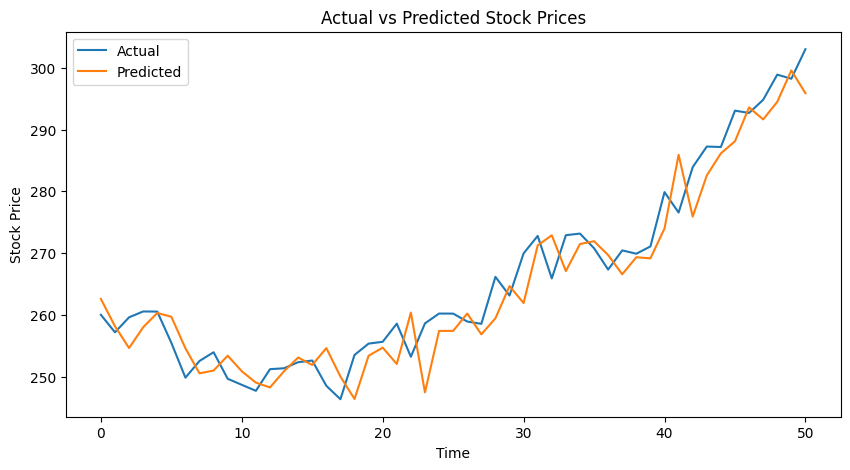

In [25]:
y_test = y_test.reset_index(drop=True)

plt.figure(figsize=(10,5))

plt.plot(y_test, label="Actual")

plt.plot(y_pred, label="Predicted")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.title("Actual vs Predicted Stock Prices")

plt.legend()

plt.show()

## Final Insights

- The Linear Regression model successfully learned patterns from historical stock data.
- Predicted prices followed the overall trend of actual prices.
- Some differences exist because stock prices are affected by many real-world factors.
- This project demonstrates the use of machine learning in financial forecasting.